## 6ª Tarefa de Oficina de Modelagem e Simulação

**Autor:** Arthur Vinícius de Oliveira Carvalho  
**Instituição:** UFMG  
**Data:** 11 de abril de 2026  

---

### Descrição
Exercícios computacionais


**1.** *Considere um sistema de primeira ordem descrito por*
$$\dot{x} = f(t, x) = −x^3, x(0) = x0$$
*Defina um certo horizonte de tempo T e escolha uma condição inicial não nula. Utilizando o que foi apresentado neste tutorial, simule o sistema para ao menos duas condições iniciais e apresente em um gráfico a evolução ao longo do tempo de x(t).*

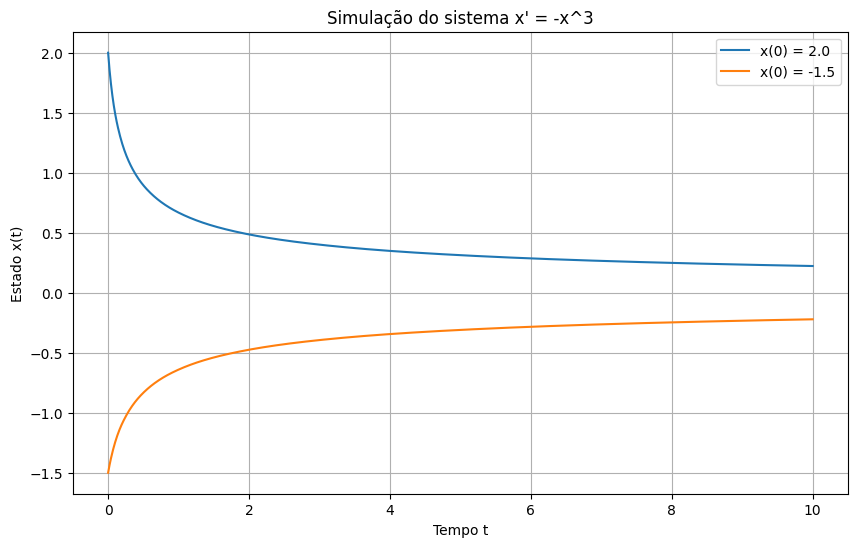

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Função que define a dinâmica do sistema
def sistema(t, x):
    return -x**3


# Horizonte de tempo
T = 10
t_span = (0, T)

# Vetor de tempo para avaliação
t_eval = np.linspace(0, T, 1000)

# Duas condições iniciais não nulas
condicoes_iniciais = [2.0, -1.5]

# Criando o gráfico
plt.figure(figsize=(10, 6))

for x0 in condicoes_iniciais:
    sol = solve_ivp(
        sistema,
        t_span,
        [x0],
        t_eval=t_eval
    )
    plt.plot(sol.t, sol.y[0], label=f"x(0) = {x0}")

plt.title("Simulação do sistema x' = -x^3")
plt.xlabel("Tempo t")
plt.ylabel("Estado x(t)")
plt.grid(True)
plt.legend()
plt.show()


---

**2.** *Seja um sistema não linear descrito pela equação diferencial*
$$\ddot{y} + 0.02\dot{y} + y + 5y^3 = 8cos(0.5t)$$
*Pede-se:*  
*a) Apresente a descrição em espaço de estados do sistema.*  
*b) Supondo condições iniciais nulas e um horizonte de tempo de, ao menos, T = 200 s, simule o comportamento do sistema e apresenta os gráficos de y(t) e $\dot{y}(t)$ ao longo do tempo. Plote também o gréfico $\dot{y}(t) × y(t)$, o qual é denominado diagrama de fase. O que é possével observar?*


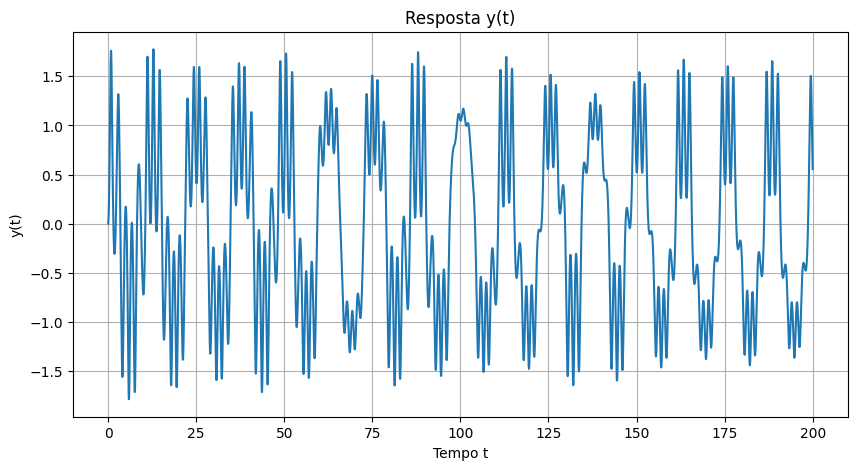

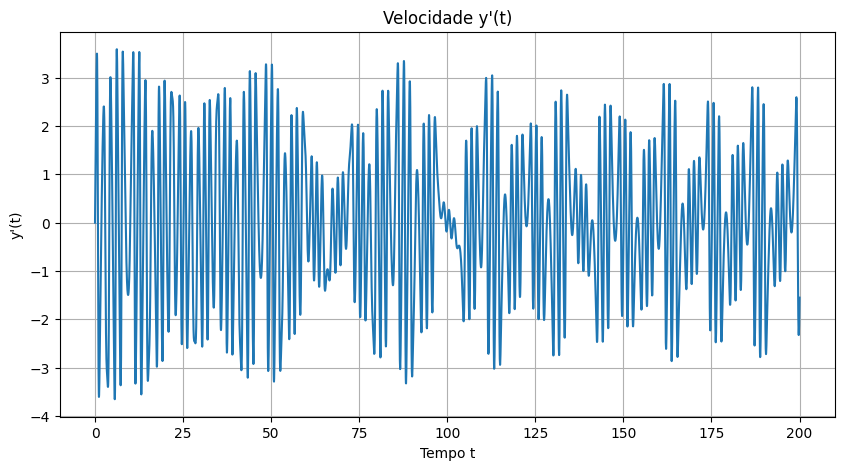

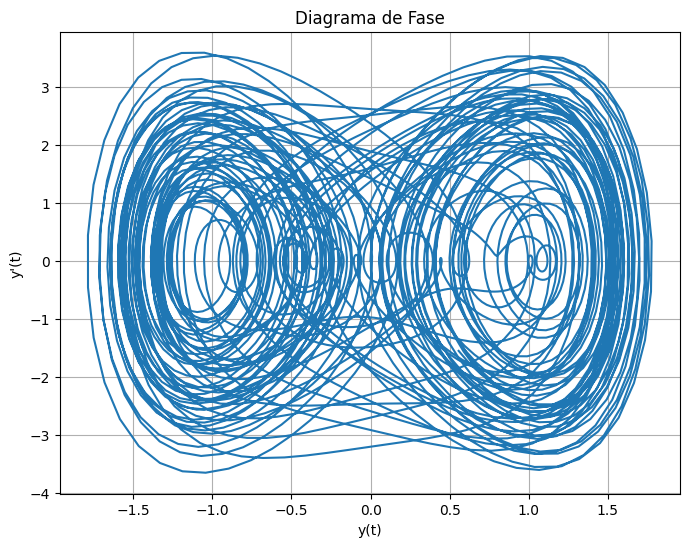

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================
# Sistema não linear:
#
# y¨ + 0.02 y˙ + y + 5y³ = 8 cos(0.5t)
#
# Definindo:
# x1 = y
# x2 = y˙
#
# Então:
#
# x1˙ = x2
# x2˙ = 8cos(0.5t) - 0.02x2 - x1 - 5x1³
#
# =====================================================

def sistema(t, x):
    x1 = x[0]  # y
    x2 = x[1]  # y'

    dx1dt = x2
    dx2dt = 8 * np.cos(0.5 * t) - 0.02 * x2 - x1 - 5 * (x1 ** 3)

    return [dx1dt, dx2dt]

# Horizonte de tempo
T = 200
t_span = (0, T)

# Pontos para avaliação
t_eval = np.linspace(0, T, 5000)

# Condições iniciais nulas
x0 = [0, 0]  # y(0)=0 e y'(0)=0

# Resolvendo numericamente
sol = solve_ivp(
    sistema,
    t_span,
    x0,
    t_eval=t_eval,
    method='RK45'
)

# Extraindo variáveis
t = sol.t
y = sol.y[0]
ydot = sol.y[1]

# Gráfico de y(t)
plt.figure(figsize=(10, 5))
plt.plot(t, y)
plt.title("Resposta y(t)")
plt.xlabel("Tempo t")
plt.ylabel("y(t)")
plt.grid(True)
plt.show()

# Gráfico de y'(t)
plt.figure(figsize=(10, 5))
plt.plot(t, ydot)
plt.title("Velocidade y'(t)")
plt.xlabel("Tempo t")
plt.ylabel("y'(t)")
plt.grid(True)
plt.show()

# Diagrama de fase (y vs y')
plt.figure(figsize=(8, 6))
plt.plot(y, ydot)
plt.title("Diagrama de Fase")
plt.xlabel("y(t)")
plt.ylabel("y'(t)")
plt.grid(True)
plt.show()


"""
O diagrama de fase mostra inicialmente um regime transitório e, após certo tempo, a trajetória 
converge para uma órbita fechada, caracterizando um ciclo limite estável. Isso indica que o sistema 
atinge regime permanente oscilatório devido à excitação periódica externa. A deformação da órbita 
em relação a uma elipse evidencia a presença da não linearidade causada pelo termo cúbico.
"""

---

**3.** *Considere o sistema massa-mola-amortecedor apresentado no Tutorial 3, o qual é reproduzido na Figura 7 e cujo modelo matemático em torno do ponto de equilíbrio estático é:*  
$$m\ddot{y}(t) + c\dot{y}(t) + ky(t) = f(t)$$
*Tomando m = 3 kg, c = 1 Ns/m e k = 10 N/m, pede-se:*  
*a) Apresente a descrição em espaço de estados dos sistema.*  
*b) Simule o sistema para f(t) = 3u(t) e apresente a evolução da posição vertical da massa m ao longo do tempo.*  
*c) Repita o item anterior, mantendo k = 10 N/m, mas escolha dois valores distintos para c, um maior e outro menor. O que é possível observar em cada caso?*  
*d) Repita o item anterior, matendo c = 1 Ns/m, mas escolha dois valores distintos para k, um maior e outro menor. O que é poss´ıvel observar em cada caso?*

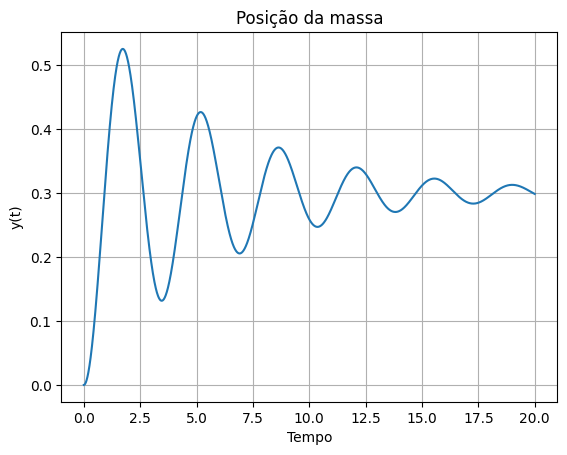

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

"""
    Definindo x1 = y e x2 = y˙, temos:
    x1˙ = x2
    x2˙ = (f - c * x2 - k * x1) / m
    f(t) = 3u(t)
"""

def massa_mola(t, x, m, c, k):
    y = x[0]
    dy = x[1]

    f = 3  # degrau unitário multiplicado por 3

    ddy = (f - c * dy - k * y) / m

    return [dy, ddy]


m = 3
c = 1
k = 10

T = 20
t_eval = np.linspace(0, T, 2000)

sol = solve_ivp(
    lambda t, x: massa_mola(t, x, m, c, k),
    (0, T),
    [0, 0],
    t_eval=t_eval
)

plt.plot(sol.t, sol.y[0])
plt.title("Posição da massa")
plt.xlabel("Tempo")
plt.ylabel("y(t)")
plt.grid()
plt.show()

"""
    Alterando c:
    c maior → sistema mais amortecido, menos oscilações
    c menor → sistema menos amortecido, mais oscilações

    Alterando k:
    k maior → sistema mais rígido, resposta mais rápida
    k menor → sistema mais lento e com maior deslocamento   
"""


---

**4.** *Considere o sistema descrito pelo seguinte par de EDOs:*
$$\ddot{x} + 4x − y = 0$$
$$\ddot{y} + cy = 0$$
*com $x(0) = \dot{x}(0) = y(0) = ˙y(0) = 1$.*  
*a) Para c = 9 e t ∈ [0, 200], simule o sistema e plote o diagrama de fase $x × \dot{x} × y$. Dica: utilize o comando plot3.*  
*b) Repita o item acima para c = 10 e com um horizonte de simulação maior. O que é possível observar com relação a ambas as figuras?*


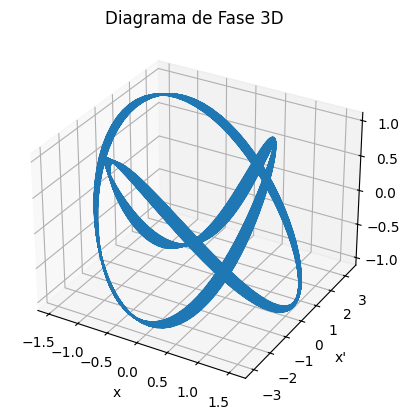

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D

"""
    Definindo x1 = x, x2 = x˙, x3 = y e x4 = y˙, temos:
    x1' = x2, x2' = -4x1 + x3, x3' = x4, x4' = -cx3
"""

def sistema4(t, x, c):
    return [
        x[1],
        -4 * x[0] + x[2],
        x[3],
        -c * x[2]
    ]


c = 9
T = 200
t_eval = np.linspace(0, T, 5000)

x0 = [1, 1, 1, 1]

sol = solve_ivp(
    lambda t, x: sistema4(t, x, c),
    (0, T),
    x0,
    t_eval=t_eval
)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    sol.y[0],  # x
    sol.y[1],  # x'
    sol.y[2]   # y
)

ax.set_xlabel("x")
ax.set_ylabel("x'")
ax.set_zlabel("y")
ax.set_title("Diagrama de Fase 3D")
plt.show()

"""
    O aumento do horizonte de simulação permite observar melhor o comportamento assintótico do sistema. 
    Para c=9, a trajetória permanece periódica e tende a formar órbitas fechadas no espaço de fase. 
    Para c=10, a trajetória não se fecha facilmente, preenchendo mais o espaço e indicando comportamento 
    quase-periódico. Assim, um horizonte maior evidencia melhor a diferença entre os dois casos.
"""